In [5]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

from src.problems import make_rastrigin
from src.stopping_criterion import ExactNonconvexCertificate
from src.optimizer import minimize
from src.evaluation import plot_2d_trace

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
sigma = 0
alpha = 0.6
eps = 1
eta0 = 2.0
# gamma = 0.51
gamma = 0.51

n = 2
x_min = np.zeros(n)
fun, true_grad, stoch_grad, L = make_rastrigin(n, A=10, sigma=sigma)

x0 = np.r_[1, 1] * 5.0


stop_criterion = ExactNonconvexCertificate(fun, sigma, alpha, eps, L, true_grad)

report_interval = 1000
x_avg_t, results = minimize(fun, stoch_grad, None, x0, eta0, gamma, stop_criterion, max_iter=500_000, verbose=True, report_interval=report_interval, true_grad=true_grad, save_trace=True)

[Iter   1000]  F(x)=43.19941 | F_avg(x)=1156.86170 | G_avg=1.0238e+04 | Cert=1076394.09291
[Iter   2000]  F(x)=73.25680 | F_avg(x)=838.09066 | G_avg=  8471.0 | Cert=772955.12032
[Iter   3000]  F(x)=56.03753 | F_avg(x)=695.47096 | G_avg=  7672.4 | Cert=637204.71106
[Iter   4000]  F(x)= 7.64445 | F_avg(x)=608.59615 | G_avg=  7187.5 | Cert=555695.20499
[Iter   5000]  F(x)= 9.32654 | F_avg(x)=548.18164 | G_avg=  6846.2 | Cert=499727.82562
[Iter   6000]  F(x)= 2.66644 | F_avg(x)=505.91056 | G_avg=  6618.9 | Cert=458369.02438
[Iter   7000]  F(x)=128.98846 | F_avg(x)=477.22035 | G_avg=  6420.4 | Cert=426001.11463
[Iter   8000]  F(x)=251.06251 | F_avg(x)=455.00635 | G_avg=  6268.0 | Cert=399857.39609
[Iter   9000]  F(x)= 8.56473 | F_avg(x)=436.61938 | G_avg=  6139.1 | Cert=378130.42842
[Iter  10000]  F(x)=100.32673 | F_avg(x)=418.75285 | G_avg=  6030.1 | Cert=359702.45256
[Iter  11000]  F(x)=26.54899 | F_avg(x)=402.44620 | G_avg=  5950.0 | Cert=343859.68732
[Iter  12000]  F(x)=27.71513 | F_avg

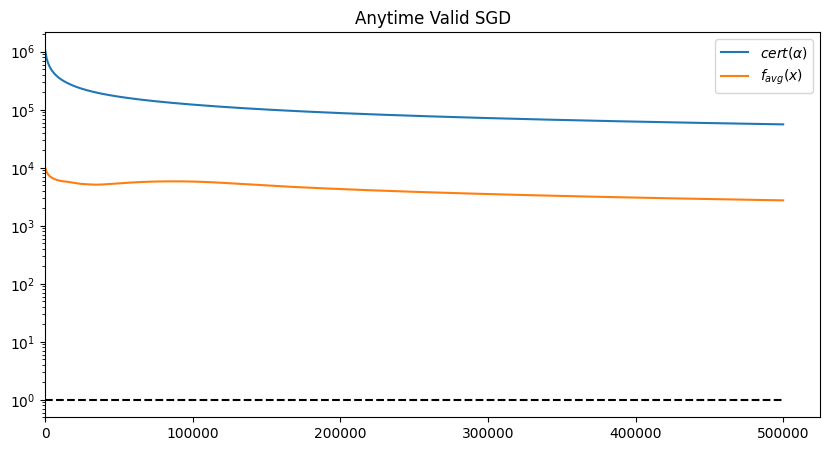

In [15]:
f = results['f']
f_avg = np.r_[results['F_avg']]
g_avg = np.r_[results['G_avg']]
cert = np.r_[results['cert']]

t = np.linspace(1, len(f) * report_interval, len(f))
plt.figure(figsize=(10, 5))
# plt.plot(t, f, label=r"$f_t(x)$")
plt.plot(t, cert, label=r"$cert(\alpha)$")
plt.plot(t, g_avg, label=r"$f_{avg}(x)$")
plt.hlines(y=eps, xmin=0, xmax=np.max(t), linestyles="--", color='black')
plt.xlim(left=0)
plt.yscale('log')
plt.legend(loc='upper right')
plt.title('Anytime Valid SGD')
plt.show()


SGD Trace X range: [-8.02, 10.39]
SGD Trace Y range: [-8.02, 10.39]
Certified Trace X range: [0.08, 0.68]
Certified Trace Y range: [0.08, 0.68]


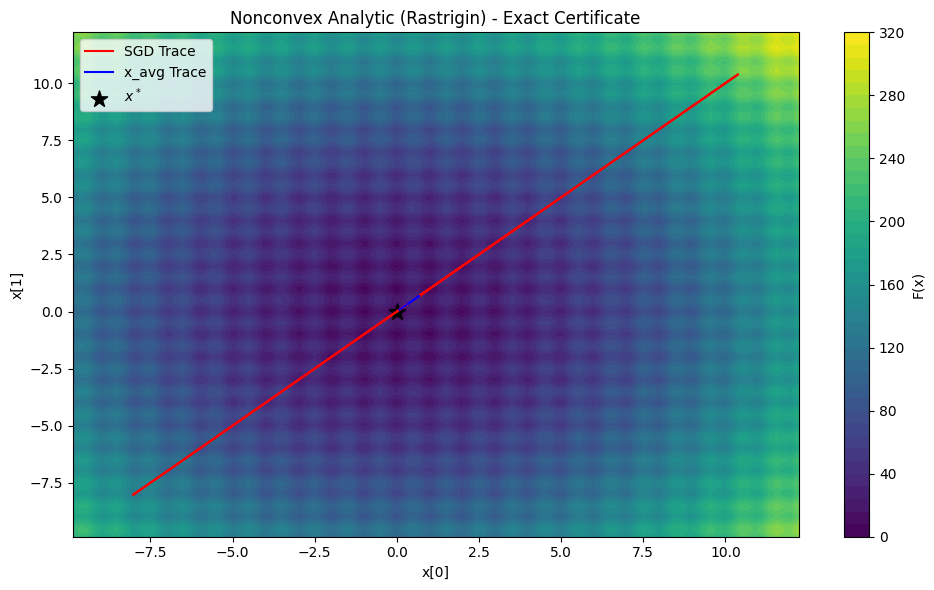

In [16]:
plot_2d_trace(results, fun, plot_type="contours", title="Nonconvex Analytic (Rastrigin) - Exact Certificate", x_min=x_min)